# Fine-tune google-bert/bert-base-uncased on Suicide Detection Dataset

This notebook prepares data, fine-tunes a BERT model, evaluates it, and saves the model locally; it is designed to run in VS Code or Colab, and includes a safe label creation path for datasets with a class column (suicide vs non-suicide) or a subreddit column.


## Quick instructions (VS Code or Colab)
- In Colab, upload this notebook via File → Upload notebook, then run cells top to bottom after placing your CSV in data/raw/.
- In VS Code, open the .ipynb directly with the Jupyter extension and run each cell sequentially after adding your CSV to data/raw/.

In [1]:
%pip install --upgrade pip
%pip install torch torchvision --quiet
%pip install transformers datasets evaluate scikit-learn pandas tqdm accelerate --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1) Prepare data
Place the Kaggle CSV into data/raw/; this cell finds the first CSV, constructs a text column, creates a binary label from either class or subreddit, cleans text, and writes train/val/test splits under data/processed/.

In [3]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

RAW_DIR = '/content/drive/MyDrive/Colab Notebooks'
PROC_DIR = '/content/drive/MyDrive/Colab Notebooks'
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

# MIN_TEXT_LENGTH = 5

# def clean_text(s: str) -> str:
#     if pd.isna(s):
#         return ''
#     s = str(s)
#     s = re.sub(r'http\S+', '', s)
#     s = re.sub(r'\s+', ' ', s).strip()
#     return s

csv_files = [f for f in os.listdir(RAW_DIR) if f.lower().endswith('.csv')]
if not csv_files:
    raise SystemExit("No CSV found in data/. Please download the Kaggle dataset and place the CSV there.")
input_csv = os.path.join(RAW_DIR, csv_files[0])
print('Using:', input_csv)
df = pd.read_csv(input_csv, engine='python', on_bad_lines='skip')
print('Columns found:', df.columns.tolist())

# if 'selftext' in df.columns:
#     df['text'] = df['selftext'].fillna('') + ' ' + df.get('title','').fillna('')
# elif 'text' in df.columns:
#     df['text'] = df['text'].fillna('')
# else:
#     # Fallback: use the first column
#     df['text'] = df.iloc[:, 0].astype(str)

if 'label' not in df.columns:
    if 'class' in df.columns:
        cls = df['class'].astype(str).str.lower().str.strip()
        # 'suicide': 1 && 'non-suicide' : 0
        df['label'] = (cls == 'suicide').astype('int8')

# df['text'] = df['text'].apply(clean_text)
# df = df[df['text'].str.len() > MIN_TEXT_LENGTH]
# print('After cleaning: rows =', len(df))

df = df[['text', 'label']]

# Train/val/test split
train, temp = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
val, test = train_test_split(temp, test_size=0.5, stratify=temp['label'], random_state=42)

train.to_csv(os.path.join(PROC_DIR, 'suicide_train.csv'), index=False)
val.to_csv(os.path.join(PROC_DIR, 'suicide_val.csv'), index=False)
test.to_csv(os.path.join(PROC_DIR, 'suicide_test.csv'), index=False)
print('Saved processed splits to', PROC_DIR)
print('Train/Val/Test sizes:', len(train), len(val), len(test))

Using: /content/drive/MyDrive/Colab Notebooks/Suicide_Detection.csv
Columns found: ['Unnamed: 0', 'text', 'class']
Saved processed splits to /content/drive/MyDrive/Colab Notebooks
Train/Val/Test sizes: 57312 7164 7164


## 2) Quick check
Preview a few preprocessed training rows to confirm text and label are present as expected.

In [ ]:
import pandas as pd, os
print(pd.read_csv(os.path.join('/content/drive/MyDrive/Colab Notebooks', 'suicide_train.csv')).head())

                                                text  label
0  Top 10 Letters of ALL time 10. K\n\n9. B\n\n8....      0
1  im always getting worseI just sat with a metho...      1
2  I wanted to go to sleep but now I feel really ...      0
3  Wish me luck Im about a week behind in math, s...      0
4  Reviewing something everyday until I find some...      0


## 3) Tokenization & datasets
Tokenize with google-bert/bert-base-uncased and load CSVs via datasets, setting PyTorch format for Trainer compatibility.

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer
import os

MODEL_CHECKPOINT = 'bert-base-uncased'
MAX_LENGTH = 128

data_files = {
    'train': os.path.join('/content/drive/MyDrive/Colab Notebooks', 'suicide_train.csv'),
    'validation': os.path.join('/content/drive/MyDrive/Colab Notebooks', 'suicide_val.csv'),
    'test': os.path.join('/content/drive/MyDrive/Colab Notebooks', 'suicide_test.csv')
}

raw_datasets = load_dataset('csv', data_files=data_files)

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, use_fast=True)

def tokenize_fn(batch):

    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )

print('Tokenizing...')
encoded = raw_datasets.map(tokenize_fn, batched=True, remove_columns=['text'])
encoded.set_format(type='torch')
print('Tokenization done. Columns:', encoded['train'].column_names)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Tokenizing...


Map:   0%|          | 0/57312 [00:00<?, ? examples/s]

Map:   0%|          | 0/7164 [00:00<?, ? examples/s]

Map:   0%|          | 0/7164 [00:00<?, ? examples/s]

Tokenization done. Columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


## 4) Model, weighted Trainer, and metrics
Define a weighted loss using CrossEntropyLoss to handle any class imbalance, and set up accuracy, precision, recall, and F1 for evaluation summaries during training and validation.

In [ ]:
import numpy as np
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.utils.class_weight import compute_class_weight
import evaluate
from torch.nn import CrossEntropyLoss

SMALL_RUN = False
BATCH_SIZE = 16
NUM_EPOCHS = 3
LR = 2e-5
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/models/suicidal-bert-finetuned'

if SMALL_RUN:
    train_ds = encoded['train'].shuffle(seed=42).select(range(2000))
    val_ds = encoded['validation'].shuffle(seed=42).select(range(500))
    test_ds = encoded['test'].shuffle(seed=42).select(range(500))
else:
    train_ds = encoded['train']
    val_ds = encoded['validation']
    test_ds = encoded['test']

train_labels = np.array(train_ds['label'])
classes = np.unique(train_labels)
class_weights = compute_class_weight('balanced', classes=classes, y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)
if torch.cuda.is_available():
    class_weights = class_weights.cuda()
print('Class weights:', class_weights)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_CHECKPOINT, num_labels=2)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels') if 'labels' in inputs else inputs.get('label')
        outputs = model(**inputs)
        logits = outputs.get('logits')

        loss_fct = CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

accuracy = evaluate.load('accuracy')
f1 = evaluate.load('f1')
precision = evaluate.load('precision')
recall = evaluate.load('recall')

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        'accuracy': accuracy.compute(predictions=preds, references=labels)['accuracy'],
        'precision': precision.compute(predictions=preds, references=labels, average='binary')['precision'],
        'recall': recall.compute(predictions=preds, references=labels, average='binary')['recall'],
        'f1': f1.compute(predictions=preds, references=labels, average='binary')['f1']
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy='epoch',
    save_strategy='epoch',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    learning_rate=LR,
    weight_decay=0.01,
    logging_dir='logs',
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=torch.cuda.is_available(),
    save_total_limit=3
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

KeyboardInterrupt: 

## 5) Train
Run training; set SMALL_RUN=True above for a quick smoke test on a small subset before full training on GPU resources.

In [4]:
trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print('Saved model to', OUTPUT_DIR)

NameError: name 'trainer' is not defined

## 6) Evaluate on test
Compute a classification report and confusion matrix on the held-out test split to confirm final performance.

In [ ]:
preds_output = trainer.predict(encoded['test'] if not SMALL_RUN else test_ds)
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
preds = np.argmax(preds_output.predictions, axis=1)
true = np.array((encoded['test'] if not SMALL_RUN else test_ds)['label'])
print(classification_report(true, preds, digits=4))


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

CONFUSION MATRIX


In [ ]:
print('Confusion matrix:\n', confusion_matrix(true, preds))

Confusion matrix:
 [[3493   98]
 [  85 3488]]


## 7) Inference helper
Load a simple pipeline for text classification to test a few example strings with the saved model and tokenizer.

In [6]:
from transformers import pipeline
import torch

OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/models/suicidal-bert-finetuned'
nlp = pipeline(
    "text-classification",
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    device=0 if torch.cuda.is_available() else -1
)

label_map = {
    "LABEL_0": "Non-Suicidal",
    "LABEL_1": "Suicidal"

}

examples = [
    "I can't handle this any longer. I don't want to be here.",
    "I've been feeling sad, but I'm trying to cope and reach out to friends.",
    "Life is beautiful, and I’m grateful for my friends and family.",
    "There’s no point in continuing anymore."
]

preds = nlp(examples)

print("\n=== Model Predictions After Fine-Tuning ===\n")
for text, result in zip(examples, preds):
    label = label_map.get(result['label'], result['label'])
    confidence = result['score'] * 100
    print(f"Text: {text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%\n")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Model Predictions After Fine-Tuning ===

Text: I can't handle this any longer. I don't want to be here.
Prediction: Suicidal
Confidence: 99.93%

Text: I've been feeling sad, but I'm trying to cope and reach out to friends.
Prediction: Suicidal
Confidence: 96.95%

Text: Life is beautiful, and I’m grateful for my friends and family.
Prediction: Suicidal
Confidence: 98.82%

Text: There’s no point in continuing anymore.
Prediction: Suicidal
Confidence: 99.97%



In [7]:
from transformers import pipeline
import torch
import pandas as pd
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/models/suicidal-bert-finetuned"

examples = [
    "I can't handle this any longer. I don't want to be here.",
    "I've been feeling sad, but I'm trying to cope and reach out to friends.",
    "Life is beautiful, and I’m grateful for my friends and family.",
    "There’s no point in continuing anymore.",
    "I feel hopeless and empty inside.",
    "i am very happy today",
    "It's a rainy day today!",
    "sup! how have you been!",
    "Alas! It's my last day...",
    "I received an offer letter yesterday",
    "Let's catch up later at my place.."
]

device = 0 if torch.cuda.is_available() else -1

base_model = pipeline(
    "text-classification",
    model="bert-base-uncased",
    tokenizer="bert-base-uncased",
    device=device
)

base_preds = base_model(examples)

fine_tuned_model = pipeline(
    "text-classification",
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    device=device,
    local_files_only = True
)

fine_preds = fine_tuned_model(examples)

label_map = {
    "LABEL_0": "Non-Suicidal",
    "LABEL_1": "Suicidal"
}

comparison = []
for text, base, fine in zip(examples, base_preds, fine_preds):
    comparison.append({
        "Text": text,
        "Base Model Prediction": label_map.get(base['label'], base['label']),
        "Base Confidence": f"{base['score']*100:.2f}%",
        "Fine-Tuned Prediction": label_map.get(fine['label'], fine['label']),
        "Fine-Tuned Confidence": f"{fine['score']*100:.2f}%"
    })

df = pd.DataFrame(comparison)
print("\n=== BERT vs Fine-Tuned Model Comparison ===\n")
print(df.to_string(index=False))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== BERT vs Fine-Tuned Model Comparison ===

                                                                   Text Base Model Prediction Base Confidence Fine-Tuned Prediction Fine-Tuned Confidence
               I can't handle this any longer. I don't want to be here.          Non-Suicidal          55.04%              Suicidal                99.93%
I've been feeling sad, but I'm trying to cope and reach out to friends.          Non-Suicidal          60.43%              Suicidal                96.95%
         Life is beautiful, and I’m grateful for my friends and family.          Non-Suicidal          57.14%              Suicidal                98.82%
                                There’s no point in continuing anymore.          Non-Suicidal          54.30%              Suicidal                99.97%
                                      I feel hopeless and empty inside.          Non-Suicidal          50.59%              Suicidal                99.90%
                              

## 8) Comparing With Other Models

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

PROC_DIR = '/content/drive/MyDrive/Colab Notebooks'
train = pd.read_csv(os.path.join(PROC_DIR, 'suicide_train.csv'))
val = pd.read_csv(os.path.join(PROC_DIR, 'suicide_val.csv'))
test = pd.read_csv(os.path.join(PROC_DIR, 'suicide_test.csv'))

print(train.shape, val.shape, test.shape)


(57312, 2) (7164, 2) (7164, 2)


In [ ]:
import os
os.makedirs("models", exist_ok=True)
all_text = pd.concat([train['text'], val['text']])

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=3)
vectorizer.fit(all_text)

X_train = vectorizer.transform(train['text'])
X_val = vectorizer.transform(val['text'])
X_test = vectorizer.transform(test['text'])

y_train = train['label'].values
y_val = val['label'].values
y_test = test['label'].values

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1),
    'LinearSVC': LinearSVC(class_weight='balanced', max_iter=5000),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1),
    'MultinomialNB': MultinomialNB()
}

results = []
for name, clf in models.items():
    print("Training", name)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary', pos_label=1)
    acc = accuracy_score(y_test, preds)
    results.append({'model': name, 'precision': precision, 'recall': recall, 'f1': f1, 'accuracy': acc})
    # Save model
    joblib.dump(clf, f'models/{name}.joblib')

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df)
results_df.to_csv('model_comparison_classical.csv', index=False)

Training LogisticRegression
Training LinearSVC
Training RandomForest
Training MultinomialNB
                model  precision    recall        f1  accuracy
1           LinearSVC   0.940202  0.937308  0.938753  0.939001
0  LogisticRegression   0.941176  0.922474  0.931731  0.932580
3       MultinomialNB   0.887059  0.949622  0.917275  0.914573
2        RandomForest   0.882043  0.889449  0.885730  0.885539


In [ ]:
# ========= Load Dataset =========
import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/suicide_train.csv")
val   = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/suicide_val.csv")
test  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/suicide_test.csv")

y_test = test['label'].values
test_texts = test['text'].tolist()

# ========= Import libraries =========
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========= Fine-Tuned BERT =========
finetuned_path = "/content/drive/MyDrive/Colab Notebooks/models/suicidal-bert-finetuned"

tokenizer_f = AutoTokenizer.from_pretrained(finetuned_path)
model_f = AutoModelForSequenceClassification.from_pretrained(finetuned_path).to(device)
model_f.eval()

# ========= BASE BERT =========
base_model_name = "bert-base-uncased"

tokenizer_b = AutoTokenizer.from_pretrained(base_model_name)
model_b = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=2
).to(device)
model_b.eval()

# ========= Prediction Function =========
def predict(texts, model, tokenizer, batch_size=32):
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

    return np.array(preds)

# ========= Predict for Fine-tuned BERT =========
preds_f = predict(test_texts, model_f, tokenizer_f)

precision_f, recall_f, f1_f, _ = precision_recall_fscore_support(
    y_test, preds_f, average="binary", pos_label=1
)
acc_f = accuracy_score(y_test, preds_f)

finetuned_results = {
    'model': 'FineTuned_BERT',
    'precision': precision_f,
    'recall': recall_f,
    'f1': f1_f,
    'accuracy': acc_f
}

# ========= Predict for Base BERT =========
preds_b = predict(test_texts, model_b, tokenizer_b)

precision_b, recall_b, f1_b, _ = precision_recall_fscore_support(
    y_test, preds_b, average="binary", pos_label=1
)
acc_b = accuracy_score(y_test, preds_b)

base_results = {
    'model': 'Base_BERT',
    'precision': precision_b,
    'recall': recall_b,
    'f1': f1_b,
    'accuracy': acc_b
}

# ========= Print Comparison =========
print("\n==== MODEL COMPARISON ====")
print("Fine-Tuned BERT:", finetuned_results)
print("Base BERT      :", base_results)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



==== MODEL COMPARISON ====
Fine-Tuned BERT: {'model': 'FineTuned_BERT', 'precision': 0.9711671749376213, 'recall': 0.9804086202071088, 'f1': 0.9757660167130919, 'accuracy': 0.97571189279732}
Base BERT      : {'model': 'Base_BERT', 'precision': 0.4794973544973545, 'recall': 0.4058214385670305, 'f1': 0.4395937547370017, 'accuracy': 0.48394751535455055}


                model  precision    recall        f1  accuracy
4                BERT   0.972672  0.976210  0.974438  0.974456
0           LinearSVC   0.946644  0.923335  0.934844  0.935790
1  LogisticRegression   0.943609  0.912983  0.928043  0.929369
2       MultinomialNB   0.890852  0.945439  0.917334  0.914992
3        RandomForest   0.886447  0.880246  0.883336  0.884003


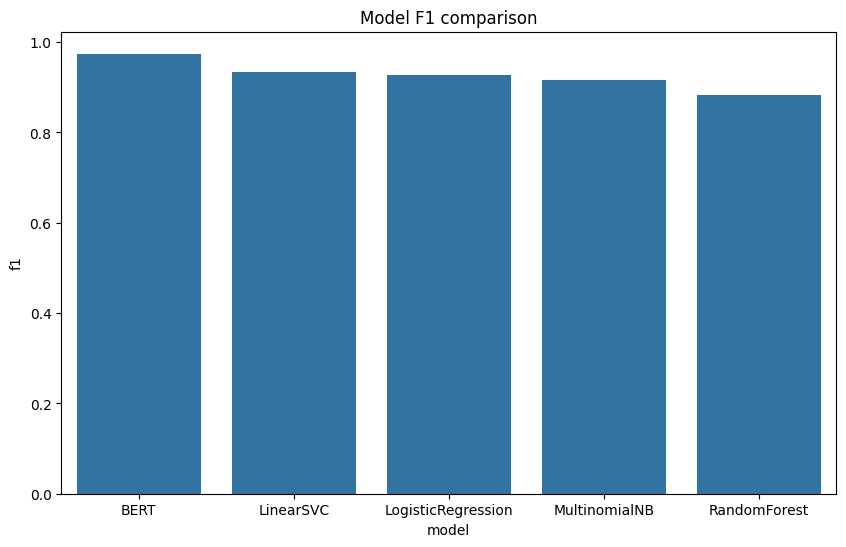

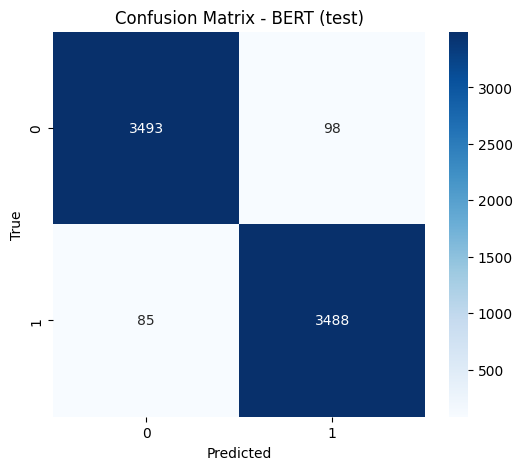

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# ✅ Add BERT results
bert_row = {
    'model': 'BERT',
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'accuracy': accuracy_score(y_test, bert_preds)
}

# ✅ Replace append with concat
bert_df = pd.DataFrame([bert_row])
results_df = pd.concat([results_df, bert_df], ignore_index=True)

# Sort and save
results_df = results_df.sort_values('f1', ascending=False)
results_df.to_csv('/content/drive/MyDrive/Colab Notebooks/model_comparison_all.csv', index=False)

print(results_df)

# 📊 Plot F1 comparison
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='model', y='f1')
plt.title('Model F1 comparison')
plt.savefig('/content/drive/MyDrive/Colab Notebooks/models/f1_comparison.png', bbox_inches='tight')
plt.show()

# 📊 Confusion Matrix for BERT
cm = confusion_matrix(y_test, bert_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - BERT (test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('/content/drive/MyDrive/Colab Notebooks/models/bert_confusion_matrix.png', bbox_inches='tight')
plt.show()
